
# Lab 05: Ensemble Learning (Digging Deeper into Random Forests).


## Learning Outcomes
*   Explain the ensemble learning paradigm and why it works
Understand that Random Forest builds multiple decision trees on different bootstrap samples and aggregates their predictions via majority vote (classification) or averaging (regression). Recognise that variance is reduced because averaging many high-variance, low-bias trees stabilises predictions. (Lecture7.pptx slide 15-17)

*   Compute and interpret Out-of-Bag (OOB) error
Understand that OOB error is computed for each training sample using only the trees that did not include that sample in their bootstrap sample. Recognise that, with sufficiently many trees, OOB error approximates cross-validation performance while being computationally cheaper. (Lecture7.pptx slide 19-20)

*   Extract and analyse individual trees
Access the estimators_ attribute of a fitted RandomForestClassifier, inspect or visualise a single decision tree, and explain why a single tree’s behaviour is not representative of the full ensemble. (Lecture7.pptx slide 22)

*   Evaluate feature importance critically
Understand that impurity-based feature importance can be biased toward high-cardinality features. Compare this with permutation importance and explain why permutation methods provide a more reliable estimate of true predictive contribution. (Lecture7.pptx slide 24-25)

*   Estimate prediction uncertainty
For classification, compute confidence scores using the proportion of trees voting for the predicted class. For regression, estimate predictive uncertainty using the variance or standard deviation across tree predictions. (Lecture7.pptx slide 15-17)

In [ ]:
import numpy as np
import pandas as pd
from sklearn import preprocessing
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.svm import SVC
from mlxtend.plotting import plot_decision_regions

## 1. Exploratory Data Analysis & The Base Problem

The dataset records the landing positions of darts on a dartboard. Each observation consists of the (x, y) coordinates of the dart impact and the identity of the person who threw the dart.

Our objective is to build a model that predicts which player threw the dart, given only the landing coordinates.

Before training the model, we examine the class distribution by plotting a histogram of the number of throws per player. This allows us to assess whether the dataset is balanced or imbalanced, which is important for selecting appropriate evaluation metrics and avoiding biased model performance.

['Bob' 'Sue' 'Kate' 'Mark']


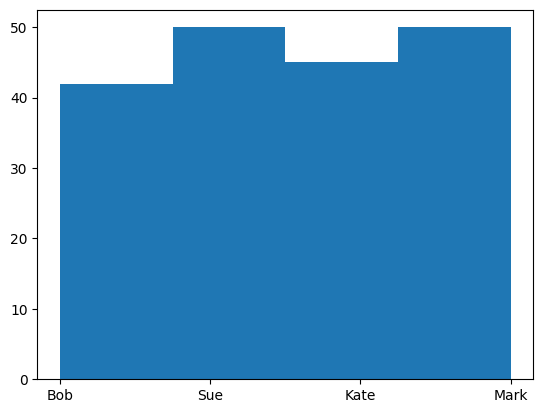

In [ ]:
darts_dataset_url = 'darts-full.csv'

full_data = pd.read_csv(darts_dataset_url)

print(full_data['Competitor'].unique())
plt.hist(full_data['Competitor'], bins=full_data['Competitor'].nunique())
plt.show()

Because the dataset is that of a dart dataset, we can visualize where the darts end up on a 2 dimensional space.

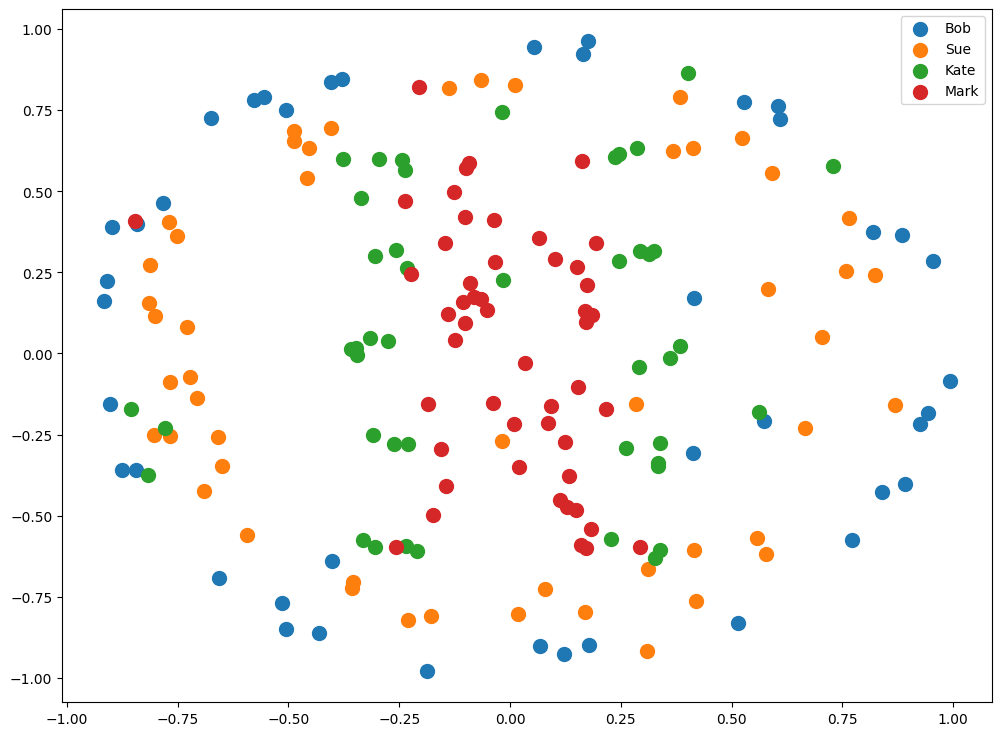

In [ ]:
plt.figure(figsize=(12,9))

for i in full_data['Competitor'].unique():
  t_indices = list(np.where(full_data['Competitor'] == i)[0])
  x_values = full_data.loc[t_indices, ["XCoord"]]
  y_values = full_data.loc[t_indices, ["YCoord"]]

  plt.scatter(x=x_values, y=y_values, s=100)

plt.legend(full_data['Competitor'].unique())
plt.show()

* Bob (blue): His shots are quite spread out and often land near the outer parts of the board. This suggests lower precision and higher variation in his throws.

* Sue (orange): Her darts are also fairly spread out, but the pattern looks a bit more organised than Bob’s. The shots cover a wide area, though not heavily concentrated in one spot.

* Kate (green): Her throws are more tightly grouped compared to Bob and Sue. The clustering shows better control and more consistent performance.

* Mark (red): His darts are clustered closest to the centre. This suggests the highest accuracy and the most consistent throwing among the four.

Lets do label encoding of the output target variable.

In [ ]:
seed = 5
np.random.seed(seed)

le = preprocessing.LabelEncoder()
le.fit(full_data['Competitor'])
full_data['Competitor'] = le.transform(full_data['Competitor'])

X_train, X_test, y_train, y_test = train_test_split(
    full_data[['XCoord', 'YCoord']], full_data['Competitor'],
    stratify=full_data['Competitor'],
    test_size=0.25, random_state=seed
)

X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

Reflection question 1: we did the encoding on competitor before the split. Is this considered as data leakage?

## 2. The Weak Learner vs. Bagging Ensemble

Let's train a single, simple Decision Tree and compare it to a Random Forest (a Bagging ensemble).


In [ ]:
# Train a baseline decision tree model

#TODO

print("DT Accuracy:", accuracy_score(y_test, y_pred_dt))

# Train a baseline random forest model. Set the following parameters: (n_estimators=100, max_depth=3, random_state=5, oob_score=True, bootstrap=True)

#TODO

print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))

DT Accuracy: 0.46808510638297873
RF Accuracy: 0.6170212765957447


There are a few things to note before we look at the results:

1. We set n_estimators = 100, meaning the Random Forest is made up of 100 decision trees.
2. We set max_depth = 3, so each tree is kept shallow to prevent overly complex rules.
3. We can understand how important features are within the random forest.
4. We enabled oob_score = True, so the model will also compute an out-of-bag (OOB) score as an extra performance estimate using the training data.

Let’s unpack what each of these settings does, one at a time.

### 2.1 The number of trees, n_estimators = 100 (Lecture7.pptx slide 15-17)

We are able to extract trees one at a time. We can find out the total number of trees via this command.

In [ ]:
#TODO


The total number of trees is 100


Every single index is a seperate tree by itself. Hence we can extract out individual trees by:

In [ ]:
single_tree = clf_rf.estimators_[0]

single_tree_predictions = single_tree.predict(X_test.iloc[[0]])

print(X_test.iloc[[0]])
print(y_test.iloc[[0]], le.inverse_transform(y_test.iloc[[0]]))
print(single_tree_predictions, le.inverse_transform(single_tree_predictions.astype(int)))

     XCoord    YCoord
0 -0.036843  0.410769
0    2
Name: Competitor, dtype: int64 ['Mark']
[2.] ['Mark']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


Although this tree predicts the instance as Kate, the ground truth label is Mark. This discrepancy suggests that the tree has followed a sequence of splits that ultimately leads to the wrong leaf node. Let us visualise the tree structure to inspect the decision boundaries responsible for this outcome.

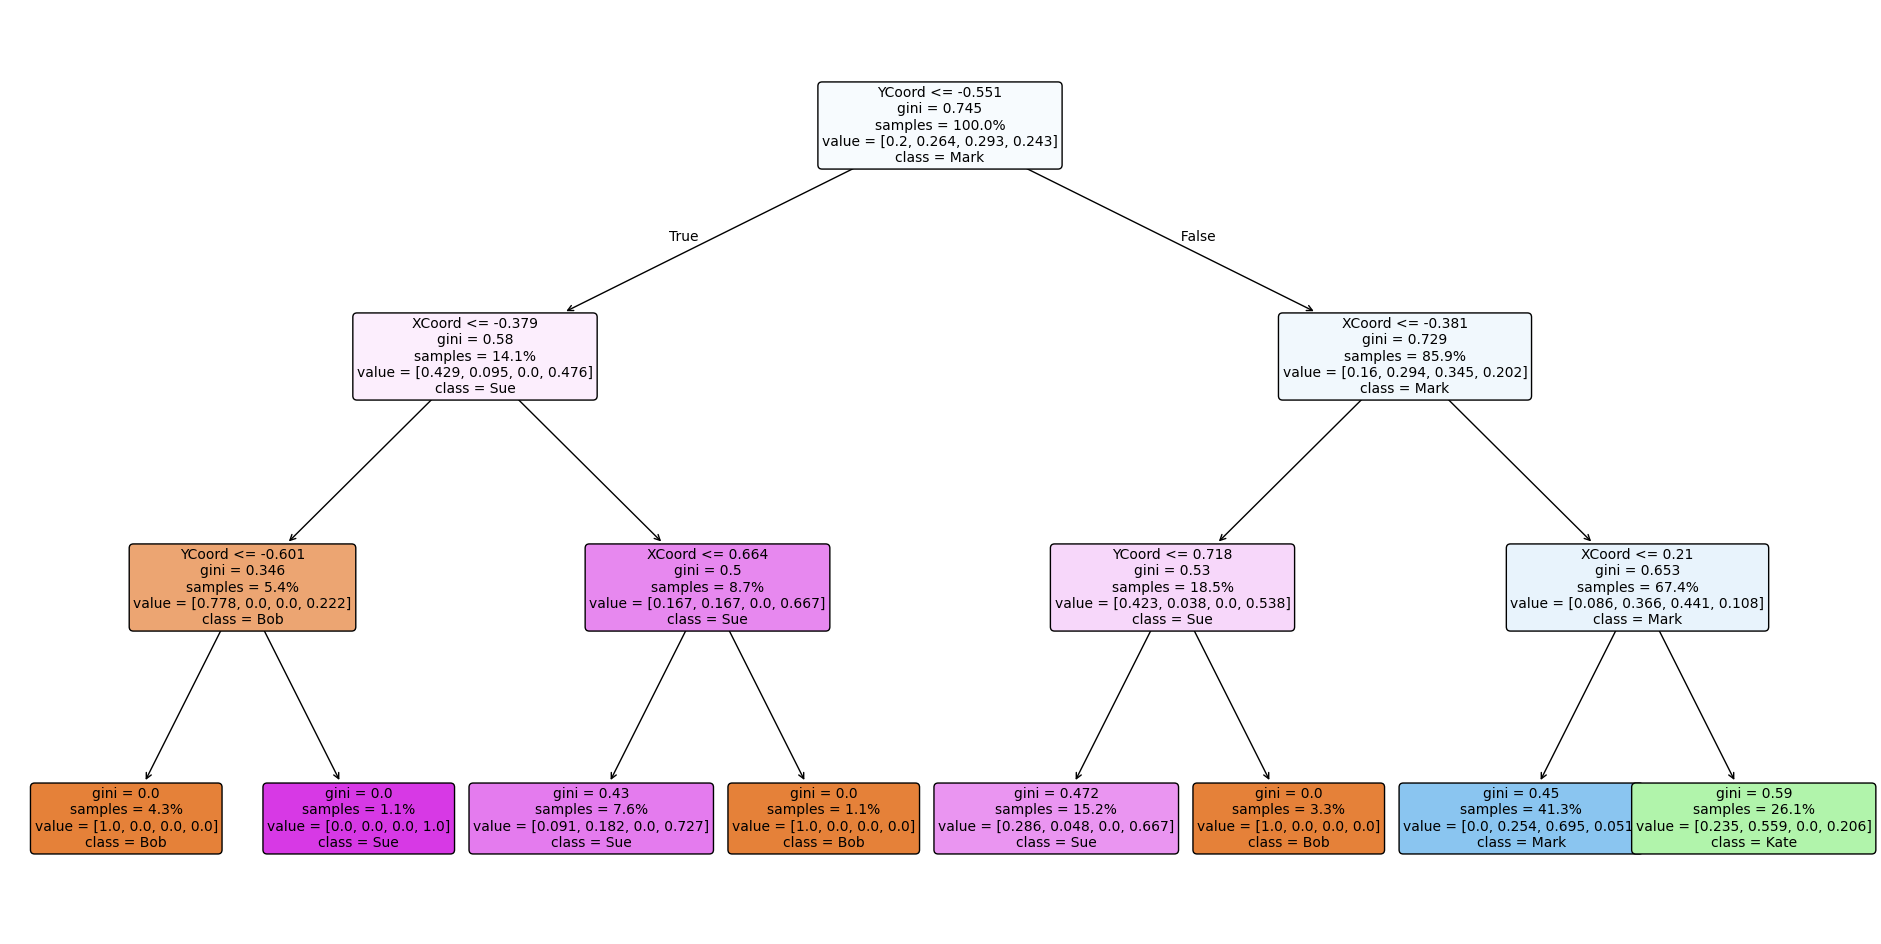

In [ ]:
import matplotlib.pyplot as plt
from sklearn import tree

single_tree = clf_rf.estimators_[65]

plt.figure(figsize=(24, 12))
tree.plot_tree(
    single_tree,
    feature_names=list(X_train.columns),
    class_names=list(le.classes_),
    filled=True,
    rounded=True,
    impurity=True,
    proportion=True,
    fontsize=10
)
plt.show()

**Step-by-step trace**

*   Root split: YCoord <= 0.709
    *   Your YCoord = 0.410769
    *   0.410769 <= 0.709 is True → go right

*   Next split (right child): YCoord <= 0.619
    *   Your XCoord = 0.410769
    *   0.410769 <= 0.619 is True → go right

*   Next split (left child): XCoord <= 0.401
    *   Your XCoord = -0.036843
    *   -0.036843 <= 0.401 is True → go right

*   Leaf reached: the leaf on the right branch of XCoord <= 0.401
    *   This leaf is labeled class = Kate in your plot.

**Note that the maximum height of this tree is 3, which corresponds to our parameter above.**

### Pen‑and‑paper: Random Forest Classification (3 classifiers)

Consider a small dataset with two classes (0 and 1).  Suppose we have three decision tree classifiers—Tree A, Tree B and Tree C.  Each tree is trained on a different bootstrap sample, so they produce slightly different predictions.  The random forest predicts the class of each point by majority vote across the trees.

#TODO FILL UP LAST COLUMN


| Data point | True label | Tree A | Tree B | Tree C | Random Forest (majority) |
|-----------|-----------|-------|-------|-------|----------------------------|
| 1         | 0         | 0     | 0     | 1     |                           |
| 2         | 1         | 1     | 0     | 1     |                           |
| 3         | 1         | 0     | 1     | 0     |                           |
| 4         | 1         | 1     | 1     | 1     |                           |
| 5         | 1         | 0     | 0     | 0     |                           |

**Steps:**

- **Collect predictions:** Evaluate each tree on the data points and record their predicted class. (Already shown for you in the chart)
- **Majority vote:** For each point, count how many trees predict class 0 versus class 1.  The random forest prediction is the class with the highest count. (todo)
- **Interpretation:** Majority voting reduces the variance of individual trees; if a single tree misclassifies a point but the others are correct, the ensemble still predicts correctly. Calculate the accuracy based on the true label (todo).

The classifier has 3 correct out of 5 observations. Accuracy is 60%.


### 2.2.1 Feature Importance of Random Forests (Lecture7.pptx slide 24-25)

There are two ways of measuring how important individual features are in random forests.

The first is the default feature importance in scikit‑learn.  It is calculated by the mean decrease in impurity (MDI), accessible via rf.feature_importances_. MDI computes how much a feature reduces the Gini impurity across the forest.

The con of feature_importance is features with high cardinalty / many unique values will appear important.

The second is known as permutation importance. Permutation importance is measured by shuffling through a feature’s values and measures the increase in prediction error.

In [ ]:
importances = clf_rf.feature_importances_
feature_names = [f"feature {i}" for i in range(X_train.shape[1])]
forest_importances = pd.Series(importances, index=feature_names)

print(forest_importances)
print(feature_names)

feature 0    0.562605
feature 1    0.437395
dtype: float64
['feature 0', 'feature 1']


How about the feature importance on the first tree?

In [ ]:
importances = clf_rf.estimators_[0].feature_importances_
feature_names = [f"feature {i}" for i in range(X_train.shape[1])]
forest_importances = pd.Series(importances, index=feature_names)

print(forest_importances)
print(feature_names)

feature 0    0.711613
feature 1    0.288387
dtype: float64
['feature 0', 'feature 1']


## Question: Computing Random Forest Feature Importance by Hand

A Random Forest classifier consists of **3 decision trees**.  
Each tree reports the following impurity-based feature importances:

| Tree   | Feature 0 | Feature 1 |
|--------|-----------|-----------|
| Tree 1 | 0.70      | 0.30      |
| Tree 2 | 0.40      | 0.60      |
| Tree 3 | 0.80      | 0.20      |

Each row sums to 1, since feature importances within a tree are normalised.

### (a) Compute the overall feature importance for the entire Random Forest.

#TODO FILL UP TABLE

| Feature | Tree 1 | Tree 2 | Tree 3 | Mean Importance |
| :--- | :--- | :--- | :--- | :--- |
| **Feature 0** | 0.70 | 0.40 | 0.80 |  |
| **Feature 1** | 0.30 | 0.60 | 0.20 |  |

### (b) Verify that the final importances sum to 1.

#TODO CALCULATE


Lets check all 100 estimators.

In [ ]:
all_importances = []
for tree in clf_rf.estimators_:
    all_importances.append(tree.feature_importances_)

df_importances = pd.DataFrame(all_importances, columns=feature_names)
print(df_importances.head())

manual_forest_importance = df_importances.mean()
print(manual_forest_importance)

   feature 0  feature 1
0   0.711613   0.288387
1   0.381626   0.618374
2   0.380140   0.619860
3   0.339940   0.660060
4   0.880177   0.119823
feature 0    0.562605
feature 1    0.437395
dtype: float64


### 2.2.2 Permutation Importance of Random Forests (Lecture7.pptx slide 24-25)

How It Works (Step by Step)

*   Train your model normally.
*   Measure baseline performance (e.g., accuracy on test set).
*   Choose one feature.
*   Randomly shuffle (permute) that feature’s values across samples.
*   This destroys any real relationship between that feature and the target.
*   All other features remain unchanged.
*   Recompute model performance.
*   Measure how much performance drops.

The importance of that feature is:

Importance = Baseline Score − Score After Shuffling

If shuffling causes a large drop, the feature was important.
If performance barely changes, the feature was not important.

In [ ]:
from sklearn.inspection import permutation_importance

# Permutation Importance
perm_result = permutation_importance(
    clf_rf,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="accuracy"
)

# Convert to DataFrame
perm_importances = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance Mean": perm_result.importances_mean,
    "Importance Std": perm_result.importances_std
}).sort_values(by="Importance Mean", ascending=False)

print("\nPermutation Importance (Test Set):")
print(perm_importances)


Permutation Importance (Test Set):
  Feature  Importance Mean  Importance Std
0  XCoord         0.306383        0.070695
1  YCoord         0.187234        0.053658


This means that when XCoord is shuffled, test accuracy drops by about 0.389 on average.

### 2.3 Out Of Bounds Estimation (Lecture7.pptx slide 19-21)

Out-of-Bag (OOB) error is an internal validation method used in bagging algorithms like Random Forest. Because each tree is trained on a bootstrap sample (a random sample with replacement), about one-third of the training data is not included in that tree’s sample. These unused samples are called “out-of-bag” samples. To compute the OOB score, each training observation is predicted using only the trees that did not see it during training, and the aggregated prediction is compared to the true label. The overall OOB error is then calculated as the average prediction error across all training samples.

### Reflection Question

When OOB is enabled, it means that you will be using samples not selected via the bootstrap algorithm to calculate the accuracy score. How do we calculate the oob_score within the forest?

In [ ]:
clf_rf.oob_score_

0.65

### Pen‑and‑paper: Calculating OOB Error (3 classifiers, 10 data points)

To understand how OOB is calculated, it is better to illustrate it step by step. Consider 10 labelled data points (1–10) with binary labels.  We train three bootstrap decision trees (Tree A, Tree B, Tree C).  For each tree, some points are *in the bag* (used for training) and the rest are *out of bag* (OOB).  The OOB error is computed by predicting each point using only the trees that did not include it in their bootstrap sample.

Suppose the bootstrap samples and OOB predictions are as follows:

### Given Information

| Data point | True label | Trees used it (in-bag) | Trees used for OOB prediction | OOB predictions (votes) |
|------------|------------|------------------------|--------------------------------|--------------------------|
| 1          | 0          | A, C                   | B                              | B: 0                     |
| 2          | 1          | B                      | A, C                           | A: 1, C: 1               |
| 3          | 0          | A                      | B, C                           | B: 0, C: 0               |
| 4          | 1          | C                      | A, B                           | A: 1, B: 1               |
| 5          | 0          | — (OOB in all)         | A, B, C                        | A: 0, B: 0, C: 0         |
| 6          | 1          | A, B                   | C                              | C: 1                     |
| 7          | 0          | A, C                   | B                              | B: 1                     |
| 8          | 1          | B, C                   | A                              | A: 1                     |
| 9          | 0          | A                      | B, C                           | B: 0, C: 0               |
| 10         | 1          | B                      | A, C                           | A: 1, C: 1               |
To compute the OOB error:

1. **Identify OOB trees:** For each data point, find which trees did *not* include it; only these trees can predict that point.
2. **Majority vote:** Take the majority vote of these OOB predictions.
3. **Compare to true label:** If the OOB majority prediction differs from the true label, it counts as an OOB error.
4. **Compute error rate:** Sum all OOB errors and divide by the number of points.  In this example, only data point 7 was mispredicted (true label 0 but OOB prediction 1), so the OOB error is 1/10 = 0.1 (10 %).

### Compute OOB Majority Prediction and Accuracy

#TODO FILL UP TABLE

| Data point | OOB majority prediction | Correct / Incorrect |
|------------|------------------------|---------------------|
| 1          |                        |                     |
| 2          |                        |                     |
| 3          |                        |                     |
| 4          |                        |                     |
| 5          |                        |                     |
| 6          |                        |                     |
| 7          |                        |                     |
| 8          |                        |                     |
| 9          |                        |                     |
| 10         |                        |                     |

Lets explain some parameters related to the OOB.

In [ ]:
print(X_train.shape)

print(clf_rf.oob_decision_function_.shape)

clf_rf.oob_decision_function_[0]

(140, 2)
(140, 4)


array([0.24237052, 0.19407692, 0.08280679, 0.48074577])

Note that the number of rows are the same as the number of rows in X_train: 140. That is because every row is given an average score to one of the four options given. This score is in fact the class / vote probabilities. 0.115 means 11.5% of the population voted for him.

In [ ]:
clf_rf.oob_decision_function_[:3]

array([[0.24237052, 0.19407692, 0.08280679, 0.48074577],
       [0.46793951, 0.17543175, 0.04151718, 0.31511156],
       [0.46033102, 0.14777496, 0.15724891, 0.23464511]])

By this will know that row one highest is at index 1, which is 0.32

Second row will be 0.52 at index 2.

Third will be 0.452 at index 3.

In [ ]:
oob_preds = np.argmax(clf_rf.oob_decision_function_, axis=1)
print(oob_preds)

[3 0 0 2 2 1 1 0 3 2 3 2 1 1 0 2 3 3 3 2 2 3 1 3 3 2 1 2 3 3 1 1 2 1 1 3 2
 2 2 2 3 0 3 2 1 2 2 0 2 2 1 0 1 3 3 3 2 1 2 3 3 0 1 0 1 2 1 3 0 3 3 3 2 2
 3 0 2 2 3 0 2 2 0 0 2 0 3 1 2 3 2 0 0 1 0 0 3 3 2 3 3 2 3 2 0 3 0 2 0 3 3
 3 1 1 0 2 0 2 3 3 2 2 0 3 1 0 0 2 2 2 3 0 1 0 2 0 3 1 2 2]


Hence if you check above, these are the actual predictions. If we compare these with y_train, we can calculate the accuracy of these predictions. You can see that we managed to back-verify the oob score from the random forest.

In [ ]:
manual_oob_score_np = np.mean(oob_preds == y_train)
print(f"Manual OOB Score (NumPy): {manual_oob_score_np}")
print(f"OOB Score (RF): {clf_rf.oob_score_}")

Manual OOB Score (NumPy): 0.65
OOB Score (RF): 0.65


During the lecture, we also talked about the OOB property of 36.8%. Lets try to verify it here. We can see the number of trees that were in the bag via the property:

In [ ]:
len(clf_rf.estimators_samples_)

100

We have 100 estimator samples, which mean that for each tree, the following data is being used. The numbers are the indices of training samples used in that bootstrap draw.

In [ ]:
clf_rf.estimators_samples_

[array([ 89,  33,  84, 105, 102,  33, 127,  87, 113,  22,  10, 122,  98,
         59,  15, 115,  35,  54, 117,  27, 123,  78,  42,  99,  29, 100,
        128,  21,  38, 131,  90,  56,  80,  30,  58,  43,  82, 118, 103,
         38,  35,  36,  81, 136, 128, 137,  38, 113,  43, 123,  51,  89,
        133, 103,  62,  79, 111,  96,  50,  64,  88,  42,  27,   7,  79,
         31, 123,  49,  72,  37,  77,  28,  72,  61, 115,  16,   4,  86,
        125,  74,  95,  67,  91, 109,  91,  17,  36, 137, 127,  51, 108,
         96,  50,  74,  48,   6,  75,  66,  43,  23, 136,  93,  83, 134,
         13,  80,  95,  84,  65,  97,  74,  10, 109,  22,  78,  99, 129,
        107,  45, 128, 121,  18,  80, 122,  75,   6,  50, 127,   0,  46,
         52, 114,  78,  22, 124,  22,  38,  72,  58, 139], dtype=int32),
 array([123,  34, 108,  12,  25,  51,  79,  44,  82,  15,  61, 103, 128,
        132, 113,  31,  45,  57,  60,  23,  12, 111, 110,  43, 127, 120,
         99,  88,  51, 113, 132, 117,  97, 102,  20

So for Tree 1 within the random forest, we use the following points within the dataframe:

```
[array([ 89,  33,  84, 105, 102,  33, 127,  87, 113,  22,  10, 122,  98,
         59,  15, 115,  35,  54, 117,  27, 123,  78,  42,  99,  29, 100,
        128,  21,  38, 131,  90,  56,  80,  30,  58,  43,  82, 118, 103,
         38,  35,  36,  81, 136, 128, 137,  38, 113,  43, 123,  51,  89,
        133, 103,  62,  79, 111,  96,  50,  64,  88,  42,  27,   7,  79,
         31, 123,  49,  72,  37,  77,  28,  72,  61, 115,  16,   4,  86,
        125,  74,  95,  67,  91, 109,  91,  17,  36, 137, 127,  51, 108,
         96,  50,  74,  48,   6,  75,  66,  43,  23, 136,  93,  83, 134,
         13,  80,  95,  84,  65,  97,  74,  10, 109,  22,  78,  99, 129,
        107,  45, 128, 121,  18,  80, 122,  75,   6,  50, 127,   0,  46,
         52, 114,  78,  22, 124,  22,  38,  72,  58, 139], dtype=int32),
```






Per tree view: how many unique training samples are used?

In [ ]:
n_samples = X_train.shape[0]          # get the number of samples used per tree
n_trees = len(clf_rf.estimators_)     # get the number of trees

unique_counts = []

for samples in clf_rf.estimators_samples_:
    unique_samples = np.unique(samples)   # for each tree, how many unique samples are used
    unique_counts.append(len(unique_samples))

unique_counts = np.array(unique_counts)

print("Average unique samples used per tree:", unique_counts.mean())
print("Average fraction used per tree:", unique_counts.mean() / n_samples)
print("Average fraction OOB per tree:", 1 - (unique_counts.mean() / n_samples))

Average unique samples used per tree: 88.87
Average fraction used per tree: 0.6347857142857143
Average fraction OOB per tree: 0.3652142857142857


Per sample view: how many trees is each sample in?

In [ ]:
oob_counts = np.zeros(n_samples)

for samples in clf_rf.estimators_samples_:
    used = np.unique(samples)
    oob = np.setdiff1d(np.arange(n_samples), used)
    oob_counts[oob] += 1

print("Number of samples:", len(oob_counts))
print("Average number of trees a sample is OOB in:", oob_counts.mean())
print("Expected ≈ 0.368 * n_trees =", 0.368 * n_trees)

Number of samples: 140
Average number of trees a sample is OOB in: 36.52142857142857
Expected ≈ 0.368 * n_trees = 36.8


In [ ]:
# oob_counts[i] = number of trees that did not use training sample i.

oob_counts

array([36., 33., 35., 40., 36., 32., 28., 39., 34., 36., 36., 40., 38.,
       28., 33., 30., 36., 43., 46., 34., 41., 29., 35., 34., 33., 38.,
       41., 38., 35., 44., 34., 34., 43., 34., 29., 40., 30., 32., 30.,
       43., 41., 37., 26., 40., 37., 39., 43., 33., 37., 30., 34., 42.,
       33., 39., 34., 37., 38., 33., 29., 40., 43., 35., 40., 36., 30.,
       33., 32., 43., 39., 37., 32., 25., 34., 38., 35., 43., 32., 37.,
       45., 43., 43., 41., 39., 34., 36., 37., 39., 34., 31., 30., 33.,
       36., 32., 33., 39., 38., 28., 34., 39., 45., 40., 31., 40., 36.,
       43., 33., 44., 40., 39., 41., 42., 39., 39., 35., 43., 36., 40.,
       38., 37., 34., 42., 41., 31., 46., 37., 37., 43., 27., 39., 33.,
       34., 34., 38., 45., 37., 38., 31., 41., 32., 32.])

We originally used this dataset to demonstrate the value of simple feature engineering. The raw input consists of the x–y coordinates of where each dart landed. However, when we transform these coordinates into a single engineered feature (the Euclidean distance from the centre) the model’s accuracy increases significantly.

In [ ]:
import numpy as np

def add_euclidean_distance_to_origin(X_train, X_test):
    """
    Adds one feature: Euclidean distance to origin (0,0).
    Returns augmented copies of X_train and X_test.
    """
    Xtr = X_train.copy()
    Xte = X_test.copy()

    Xtr["dist_euclidean"] = np.sqrt(Xtr["XCoord"]**2 + Xtr["YCoord"]**2)
    Xte["dist_euclidean"] = np.sqrt(Xte["XCoord"]**2 + Xte["YCoord"]**2)

    return Xtr, Xte

In [ ]:
X_train_aug, X_test_aug = add_euclidean_distance_to_origin(X_train, X_test)

baseline_features = ["XCoord", "YCoord"]
engineered_features = ["XCoord", "YCoord", "dist_euclidean"]

dt = DecisionTreeClassifier(max_depth=3, random_state=5)
dt.fit(X_train_aug[engineered_features], y_train)
print("DT Accuracy (with dist):", accuracy_score(y_test, dt.predict(X_test_aug[engineered_features])))

rf = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=5, bootstrap=True)
rf.fit(X_train_aug[engineered_features], y_train)
print("RF Accuracy (with dist):", accuracy_score(y_test, rf.predict(X_test_aug[engineered_features])))

DT Accuracy (with dist): 0.723404255319149
RF Accuracy (with dist): 0.7659574468085106


### Practice Questions

Q1. Individual Tree Behaviour in Random Forest

A trained RandomForestClassifier has 100 trees with max_depth=3, bootstrap=True, and oob_score=True.

Which statements are TRUE? Select ALL that apply.

A.   Each individual tree is trained on the full dataset but different feature subsets.

B.   Individual trees may disagree with the final forest prediction.

C.   Extracting rf.estimators_[0] yields a fully functional DecisionTreeClassifier.

D.   The maximum depth of each tree is exactly 3 for all trees.

E.   A single extracted tree will always achieve lower training error than the full forest.

Q2. OOB Conceptual Understanding

Which statements are TRUE?

A. OOB is computed using predictions from trees that did not include that sample in their bootstrap training.

B. OOB uses approximately 36.8% of trees per sample.

C. OOB is an unbiased estimator of test error for sufficiently many trees.

D. OOB error is always lower than training error.

E. Setting bootstrap=False invalidates OOB computation.

Q3. Feature Engineering (Distance to Origin Example)

From final section of lab, transforming (XCoord, YCoord) into Euclidean distance to origin.

Which are TRUE?

A. This reduces dimensionality from 2 to 1.

B. This transformation removes angular information.

C. This transformation preserves all information from the original features.

D. A tree-based model does not benefit from such transformation.

E. This imposes circular decision boundaries.

There is an old version of this lab which focuses on other learning points:

https://colab.research.google.com/drive/1j5dVBX6rwSqQVLh1j_7JhMx9-8uMB0ur?usp=sharing

It is good also but focuses on many new things. Some of you however may be interested in it hence I included it here for your reference.